# 11. Linear Programming Fundamentals & Reading Solver Output

Every model in this series has ended with the same line: `n.optimize(solver_name='highs')`. This
notebook opens that line up. PyPSA doesn't have any special intelligence of its own — it takes the
network you've built and translates it into a **linear program (LP)**: a set of decision variables,
a linear objective function to minimize, and a set of linear constraints. A solver (HiGHS, in this
series) then finds the variable values that minimize the objective without violating any constraint.
Everything from Models 01-10 has secretly been this same recipe, just with more variables.

An LP has three ingredients:
1. **Decision variables** - the unknowns the solver is free to choose (in PyPSA: how much each
   generator, storage unit, and link dispatches in each hour).
2. **An objective function** - a linear combination of the decision variables to minimize (in PyPSA:
   total `marginal_cost x dispatch`, summed across every component and every hour).
3. **Constraints** - linear equations or inequalities the solution must satisfy (in PyPSA: generator
   capacity limits, `p_min_pu`/`p_max_pu` bounds, and the requirement that supply equals demand at
   every bus in every hour).

This notebook works a tiny two-generator problem by hand, solves the exact same problem three ways -
manually, as a standalone LP, and as a PyPSA network - and confirms all three agree, then uses that
tiny example to explain what a **shadow price** (in PyPSA: `n.buses_t.marginal_price`) actually
means.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import linprog
import pypsa
import sys

sys.path.append('../')
from utils.viz_utils import set_nature_style
set_nature_style()


## Toy Problem: Meeting a Fixed Demand from Two Generators

Two generators sit on the same bus and must jointly meet a fixed 12 MW demand for a single hour:

- **Generator A**: capacity 8 MW, costs 20 EUR/MWh
- **Generator B**: capacity 10 MW, costs 35 EUR/MWh

Since demand (12 MW) exceeds Generator A's capacity (8 MW) alone, both generators are needed. The
cheapest way to meet the demand is to use as much of the cheap generator as possible, then cover the
remainder with the expensive one - this is the **merit order**, and it's intuitive enough to solve
by hand before treating it as an optimization problem at all.


In [2]:
demand_mw = 12.0
gen_a_cap, gen_a_cost = 8.0, 20.0
gen_b_cap, gen_b_cost = 10.0, 35.0

# Hand solution: use all of the cheap generator first, then cover the rest with the expensive one
dispatch_a_hand = min(demand_mw, gen_a_cap)
dispatch_b_hand = demand_mw - dispatch_a_hand
total_cost_hand = dispatch_a_hand * gen_a_cost + dispatch_b_hand * gen_b_cost

print(f"Generator A dispatch: {dispatch_a_hand:.2f} MW")
print(f"Generator B dispatch: {dispatch_b_hand:.2f} MW")
print(f"Total cost: EUR {total_cost_hand:,.2f}")


Generator A dispatch: 8.00 MW
Generator B dispatch: 4.00 MW
Total cost: EUR 300.00


## The Same Problem, Written as a Linear Program

Formally, this problem is:

$$\min_{x_A, x_B} \quad 20 x_A + 35 x_B$$

$$\text{subject to} \quad x_A + x_B = 12, \quad 0 \le x_A \le 8, \quad 0 \le x_B \le 10$$

where $x_A$ and $x_B$ are the two decision variables (each generator's dispatch). `scipy.optimize`'s
`linprog` solves exactly this kind of problem directly, given the objective coefficients, the
equality constraint, and the variable bounds.


In [3]:
# Objective: minimize 20*x_A + 35*x_B
c = [gen_a_cost, gen_b_cost]

# Equality constraint: x_A + x_B = 12
A_eq = [[1, 1]]
b_eq = [demand_mw]

# Bounds: 0 <= x_A <= 8, 0 <= x_B <= 10
bounds = [(0, gen_a_cap), (0, gen_b_cap)]

result = linprog(c, A_eq=A_eq, b_eq=b_eq, bounds=bounds, method='highs')

print(f"Generator A dispatch: {result.x[0]:.2f} MW")
print(f"Generator B dispatch: {result.x[1]:.2f} MW")
print(f"Total cost: EUR {result.fun:,.2f}")
print(f"Matches hand solution: {np.isclose(result.fun, total_cost_hand)}")


Generator A dispatch: 8.00 MW
Generator B dispatch: 4.00 MW
Total cost: EUR 300.00
Matches hand solution: True


## The Same Problem, as a One-Hour PyPSA Network

A PyPSA `Network` with two generators, a single bus, and a single-hour load is exactly the LP above -
`p_nom` becomes the variable bound, `marginal_cost` becomes the objective coefficient, and the bus's
power balance becomes the equality constraint. Nothing here is a new mechanic from earlier models;
this is the same `Generator` and `Load` syntax used since Model 01, just reduced to one hour and two
generators so every term in the LP can be seen directly.


In [4]:
n = pypsa.Network()
n.set_snapshots([0])

n.add("Bus", "toy_bus")
n.add("Generator", "Generator_A", bus="toy_bus", p_nom=gen_a_cap, marginal_cost=gen_a_cost)
n.add("Generator", "Generator_B", bus="toy_bus", p_nom=gen_b_cap, marginal_cost=gen_b_cost)
n.add("Load", "Toy_Demand", bus="toy_bus", p_set=demand_mw)

status, condition = n.optimize(solver_name='highs')

print(f"Generator A dispatch: {n.generators_t.p['Generator_A'].iloc[0]:.2f} MW")
print(f"Generator B dispatch: {n.generators_t.p['Generator_B'].iloc[0]:.2f} MW")
print(f"Total cost: EUR {n.objective:,.2f}")


Index(['toy_bus'], dtype='object', name='Bus')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.02s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 2 primals, 5 duals
Objective: 3.00e+02
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper were not assigned to the network.


Generator A dispatch: 8.00 MW
Generator B dispatch: 4.00 MW
Total cost: EUR 300.00


All three approaches agree, because they're the same optimization problem written three
different ways. Every PyPSA network in this series has simply been this LP, scaled up to thousands of
variables (one per generator, storage unit, and link, per snapshot) and thousands of constraints
(capacity bounds and power balance, per bus, per snapshot) - solved by the same HiGHS solver underneath.

## Shadow Prices: What Does the Last MWh Cost?

Beyond the dispatch itself, every constraint in an LP has an associated **shadow price** (also called
a dual value or, in PyPSA, the `marginal_price`): the amount the objective would change if that
constraint were relaxed by one unit. For the power-balance constraint at a bus, the shadow price has
a very direct meaning - it's **the cost of supplying one more MW of demand at that bus, in that
hour**, using whatever generator is next in the merit order (or, if a generator is exactly at its
capacity limit, the price can be lower or higher than that generator's own marginal cost, since the
constraint itself is what's binding).

In the toy problem above, demand is 12 MW: Generator A supplies its full 8 MW, and Generator B (the
more expensive option, at 35 EUR/MWh) supplies the remaining 4 MW. Since Generator B is the one meeting
the marginal MW of demand, the shadow price at `toy_bus` should equal Generator B's marginal cost -
not Generator A's, even though Generator A is cheaper and supplies more of the total energy.


In [5]:
shadow_price = n.buses_t.marginal_price['toy_bus'].iloc[0]

print(f"Shadow price at toy_bus: EUR {shadow_price:.2f}/MWh")
print(f"Generator B's marginal cost: EUR {gen_b_cost:.2f}/MWh")
print("These match because Generator B is the marginal (price-setting) generator.")


Shadow price at toy_bus: EUR 35.00/MWh
Generator B's marginal cost: EUR 35.00/MWh
These match because Generator B is the marginal (price-setting) generator.


## Shadow Prices Across a Full Year

The same idea scales directly to a full year of hourly snapshots. Reusing a solar, wind, and grid
connection setup, the marginal price at `electricity_bus` in each hour reflects whichever generator
was setting the price in that hour. Whenever the grid connection has spare capacity, it can always
absorb or supply the next MW at exactly the market price, so the bus price simply equals the market
price. The interesting case is when the **export capacity itself becomes the binding constraint** -
in hours where solar and wind together exceed both the load and the export limit, the excess has
nowhere to go and must be curtailed. In those hours, the shadow price is set by the curtailed
generator's own (zero) marginal cost instead of the market price, since no constraint forces the
system to pay for power it's physically unable to deliver anywhere.


Index(['electricity_bus'], dtype='object', name='Bus')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 1/1 [00:00<00:00, 10.52it/s]
INFO:linopy.io: Writing time: 0.58s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 35040 primals, 78840 duals
Objective: -1.05e+06
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper were not assigned to the network.


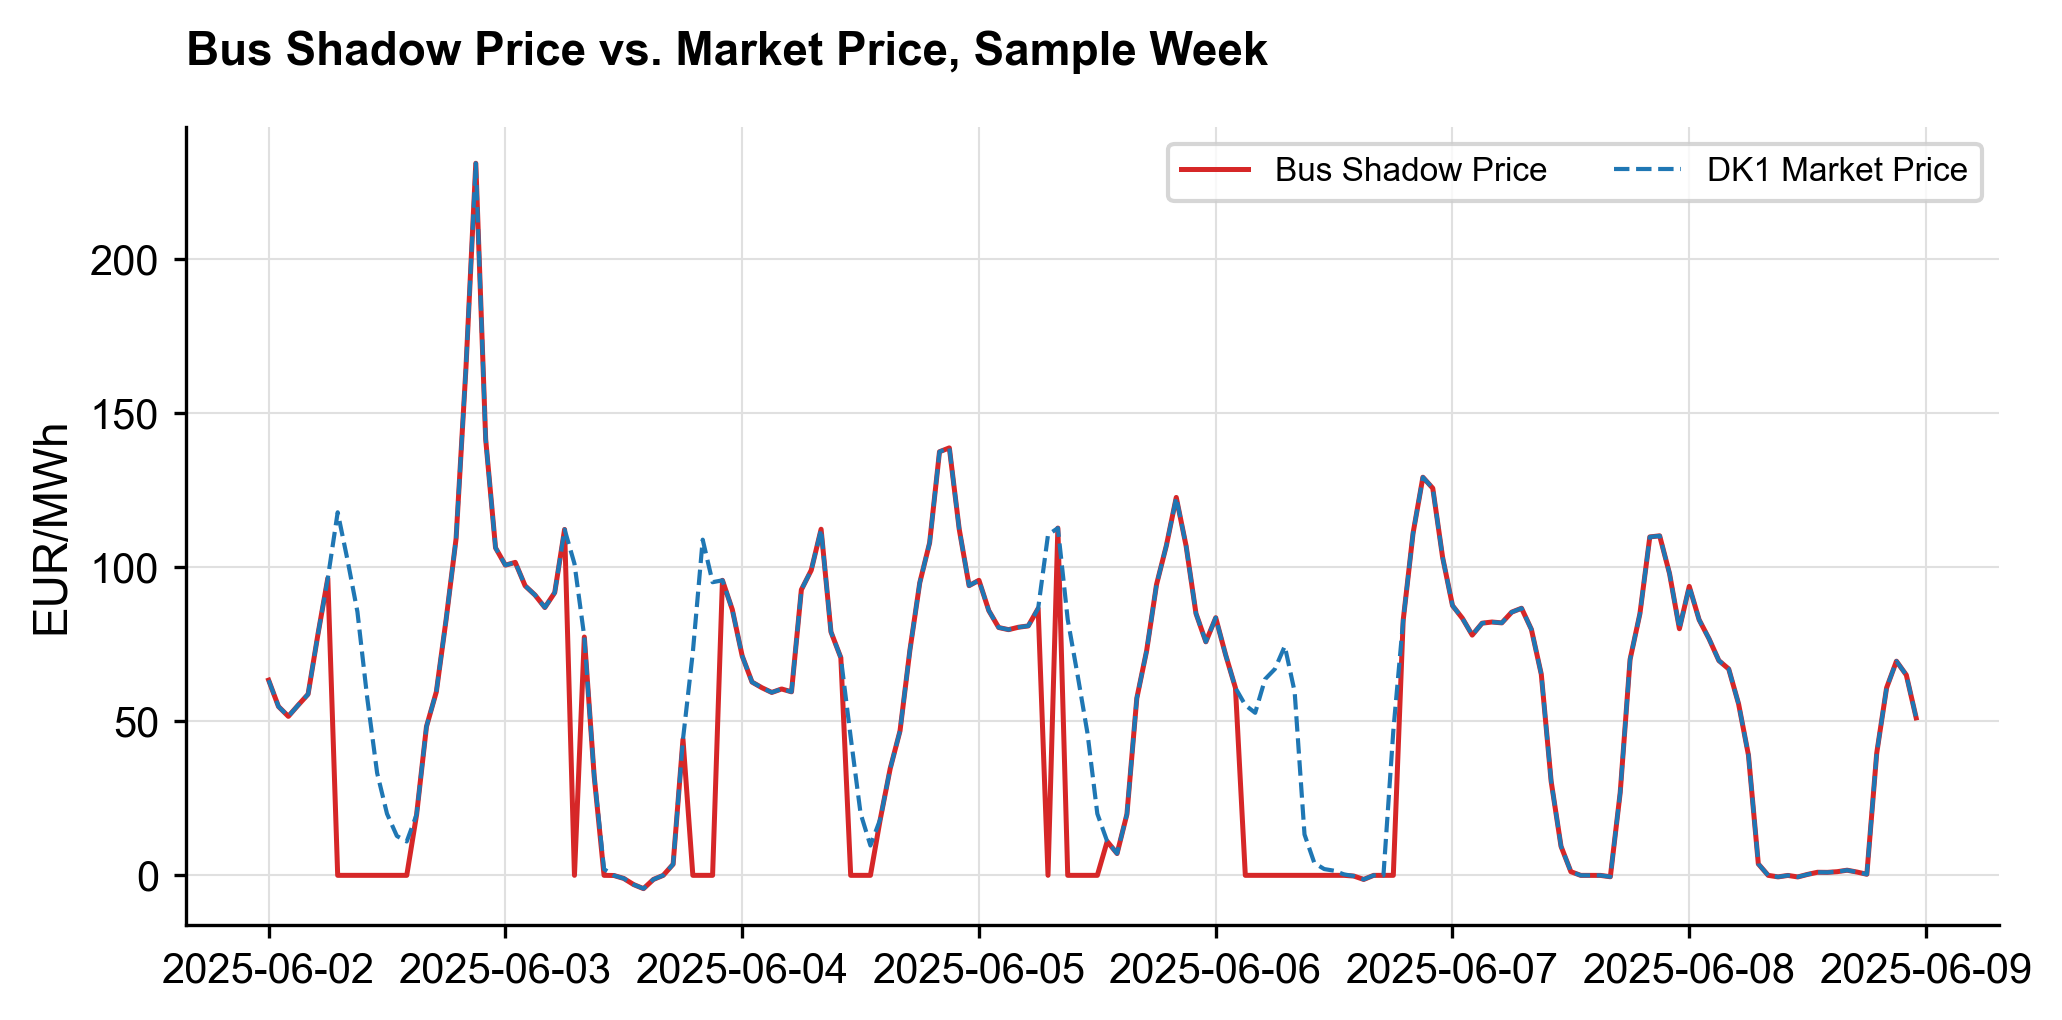

Hours where the bus price equals the market price (grid connection not binding): 6837 / 8760
Hours where the bus price is below the market price (export capacity binding, RE curtailed): 1922 / 8760


In [6]:
df_pv = pd.read_csv('../data/processed/pv_2025_hourly.csv', index_col='time', parse_dates=True)
df_wind = pd.read_csv('../data/processed/wind_2025_hourly.csv', index_col='time', parse_dates=True)
df_price = pd.read_csv('../data/processed/electricity_price_2025_hourly.csv', index_col='time', parse_dates=True)

perfect_index = pd.date_range(start='2025-01-01 00:00', end='2025-12-31 23:00', freq='1h')
df_pv.index = perfect_index
df_wind.index = perfect_index
df_price.index = perfect_index

df_pv['capacity_factor'] = df_pv['pv_generation_kw'].clip(upper=1.0)
df_wind['capacity_factor'] = df_wind['wind_generation_kw'].clip(upper=1.0)

n2 = pypsa.Network()
n2.set_snapshots(df_pv.index)
n2.add("Bus", "electricity_bus")

n2.add("Generator", "Solar_PV", bus="electricity_bus", p_nom=10.0,
       p_max_pu=df_pv['capacity_factor'], marginal_cost=0.0)
n2.add("Generator", "Wind", bus="electricity_bus", p_nom=15.0,
       p_max_pu=df_wind['capacity_factor'], marginal_cost=0.0)
n2.add("Generator", "Grid_Import", bus="electricity_bus", p_nom=20.0, marginal_cost=df_price['price'])
n2.add("Generator", "Grid_Export", bus="electricity_bus", p_nom=6.0,
       p_min_pu=-1.0, p_max_pu=0.0, marginal_cost=df_price['price'])

is_daytime = (n2.snapshots.hour >= 8) & (n2.snapshots.hour < 18)
load_profile = np.where(is_daytime, 8.0, 4.0)
n2.add("Load", "Industrial_Load", bus="electricity_bus", p_set=pd.Series(load_profile, index=n2.snapshots))

status, condition = n2.optimize(solver_name='highs')

marginal_price = n2.buses_t.marginal_price['electricity_bus']

# One representative week: compare the bus's shadow price against the DK1 market price
week = (n2.snapshots >= '2025-06-02') & (n2.snapshots < '2025-06-09')

fig, ax = plt.subplots()
ax.plot(n2.snapshots[week], marginal_price[week], color='#d62728', linewidth=1.2, label='Bus Shadow Price')
ax.plot(n2.snapshots[week], df_price['price'][week], color='#1f77b4', linewidth=1.0, linestyle='--', label='DK1 Market Price')
ax.set_ylabel('EUR/MWh')
ax.set_title('Bus Shadow Price vs. Market Price, Sample Week', pad=15, loc='left', fontweight='bold')
ax.legend(loc='upper right', ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

hours_price_below_market = (marginal_price < df_price['price'] - 0.01).sum()
hours_price_equals_market = (np.abs(marginal_price - df_price['price']) <= 0.01).sum()

print(f"Hours where the bus price equals the market price (grid connection not binding): {hours_price_equals_market} / {len(n2.snapshots)}")
print(f"Hours where the bus price is below the market price (export capacity binding, RE curtailed): {hours_price_below_market} / {len(n2.snapshots)}")
